In [58]:
import numpy as np # for linear algebra
import pandas as pd # data processing, CSV file I/O, etc
import seaborn as sns # for plots
import plotly.graph_objects as go # for plots
import plotly.express as px #for plots
import matplotlib.pyplot as plt # for visualizations and plots



In [59]:
from pylab import rcParams
rcParams['figure.figsize'] = 15, 10

import random # random library
pallete = ['Accent_r', 'Blues', 'BrBG', 'BrBG_r', 'BuPu', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'OrRd', 'Oranges', 'Paired', 'PuBu', 'PuBuGn', 'PuRd', 'Purples', 'RdGy_r', 'RdPu', 'Reds', 'autumn', 'cool', 'coolwarm', 'flag', 'flare', 'gist_rainbow', 'hot', 'magma', 'mako', 'plasma', 'prism', 'rainbow', 'rocket', 'seismic', 'spring', 'summer', 'terrain', 'turbo', 'twilight']

In [60]:
from sklearn.model_selection import train_test_split # spliting training and testing data
from sklearn.preprocessing import MinMaxScaler # data normalization with sklearn
from sklearn.preprocessing import StandardScaler # data standardization with  sklearn
from sklearn.ensemble import RandomForestClassifier # model
from sklearn.linear_model import LogisticRegression # model
from sklearn.neighbors import KNeighborsClassifier # model
from sklearn.metrics import classification_report, confusion_matrix # to evaluate the model

from sklearn.model_selection import GridSearchCV # to finetune the model


In [61]:
df = pd.read_csv("diabetes.csv")
df.head() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
df["Glucose"] = df["Glucose"].apply(lambda x: np.nan if x == 0 else x)
df["BloodPressure"] = df["BloodPressure"].apply(lambda x: np.nan if x == 0 else x)
df["SkinThickness"] = df["SkinThickness"].apply(lambda x: np.nan if x == 0 else x)
df["Insulin"] = df["Insulin"].apply(lambda x: np.nan if x == 0 else x)
df["BMI"] = df["BMI"].apply(lambda x: np.nan if x == 0 else x)

In [15]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

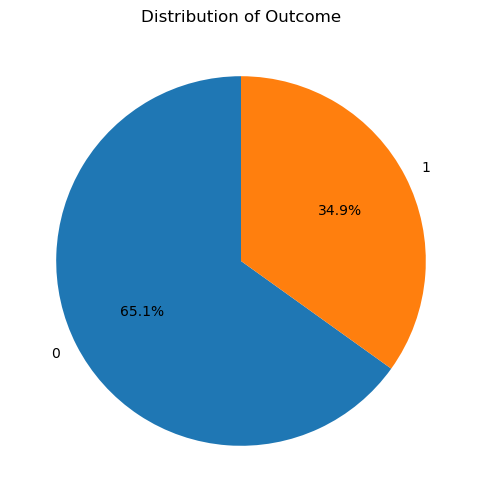

In [68]:
counts = df["Outcome"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Distribution of Outcome")
plt.show()

<Axes: xlabel='Outcome', ylabel='count'>

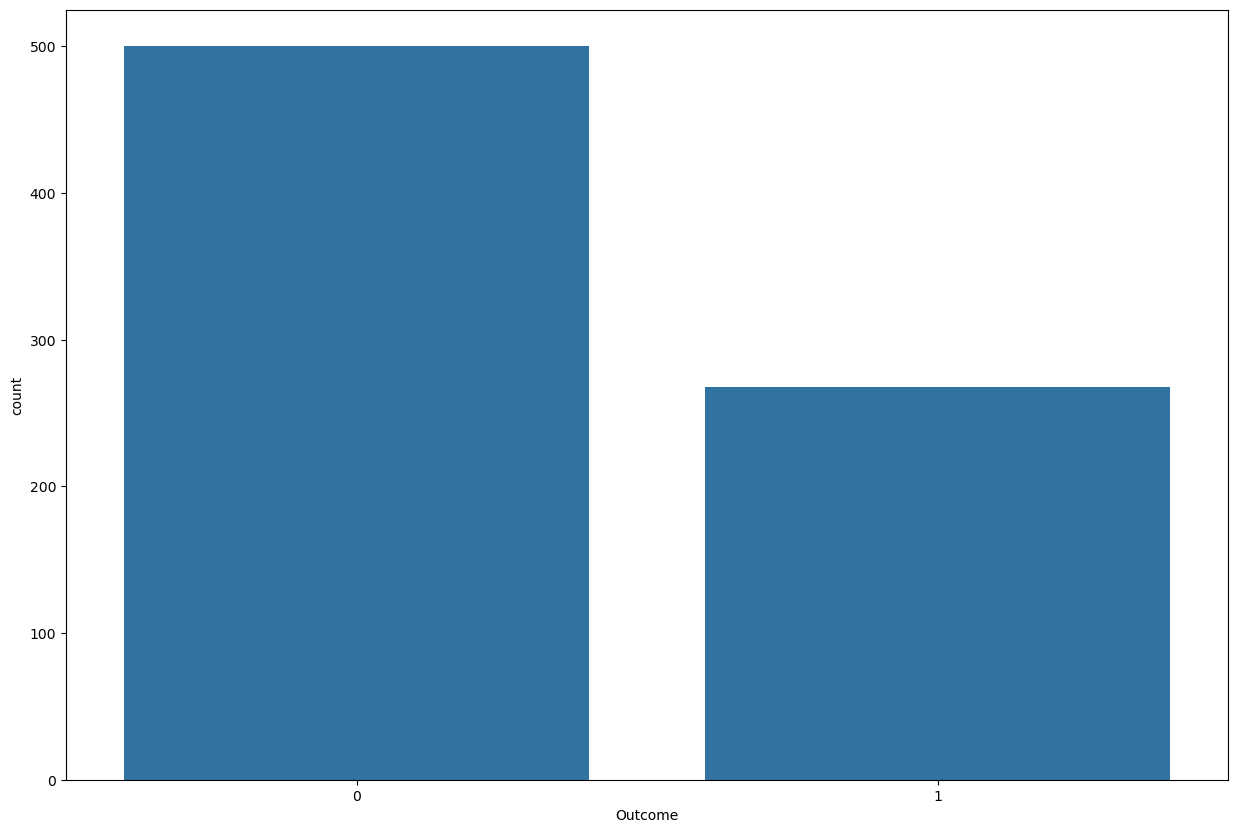

In [21]:
sns.countplot(x="Outcome", data=df,)

<Axes: xlabel='Pregnancies', ylabel='count'>

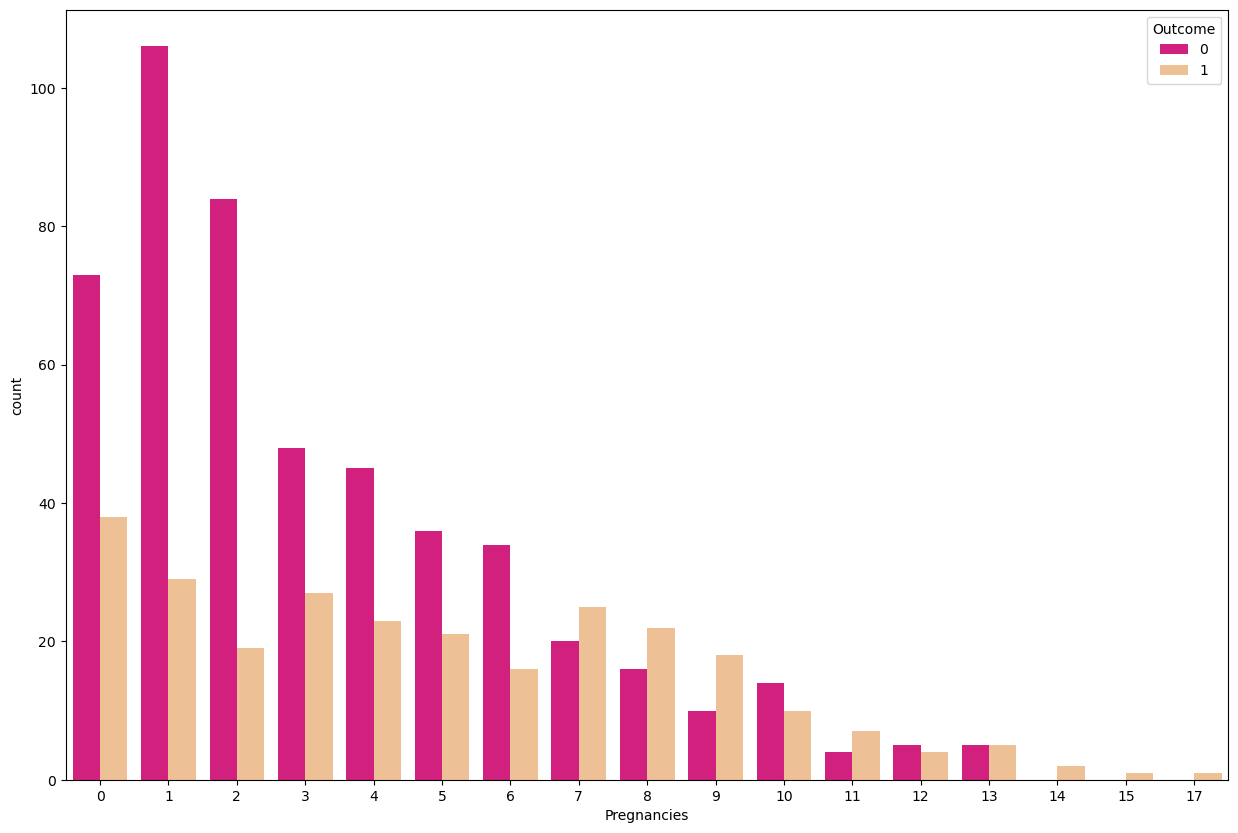

In [22]:
sns.countplot(x="Pregnancies", hue = "Outcome", data=df, palette=random.choice(pallete))

<Axes: xlabel='BloodPressure', ylabel='Count'>

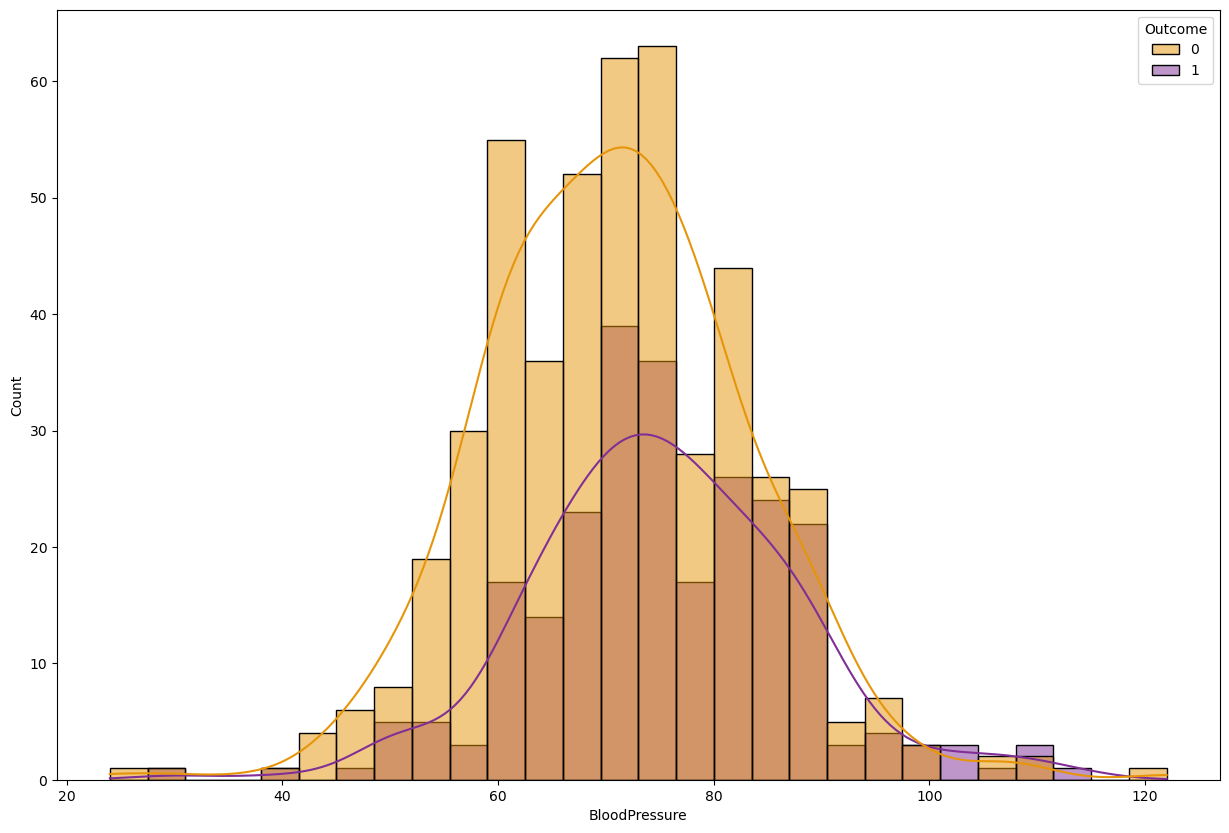

In [24]:
sns.histplot(x="BloodPressure", hue="Outcome", data=df, kde=True, palette=random.choice(pallete))

<Axes: xlabel='Glucose', ylabel='Count'>

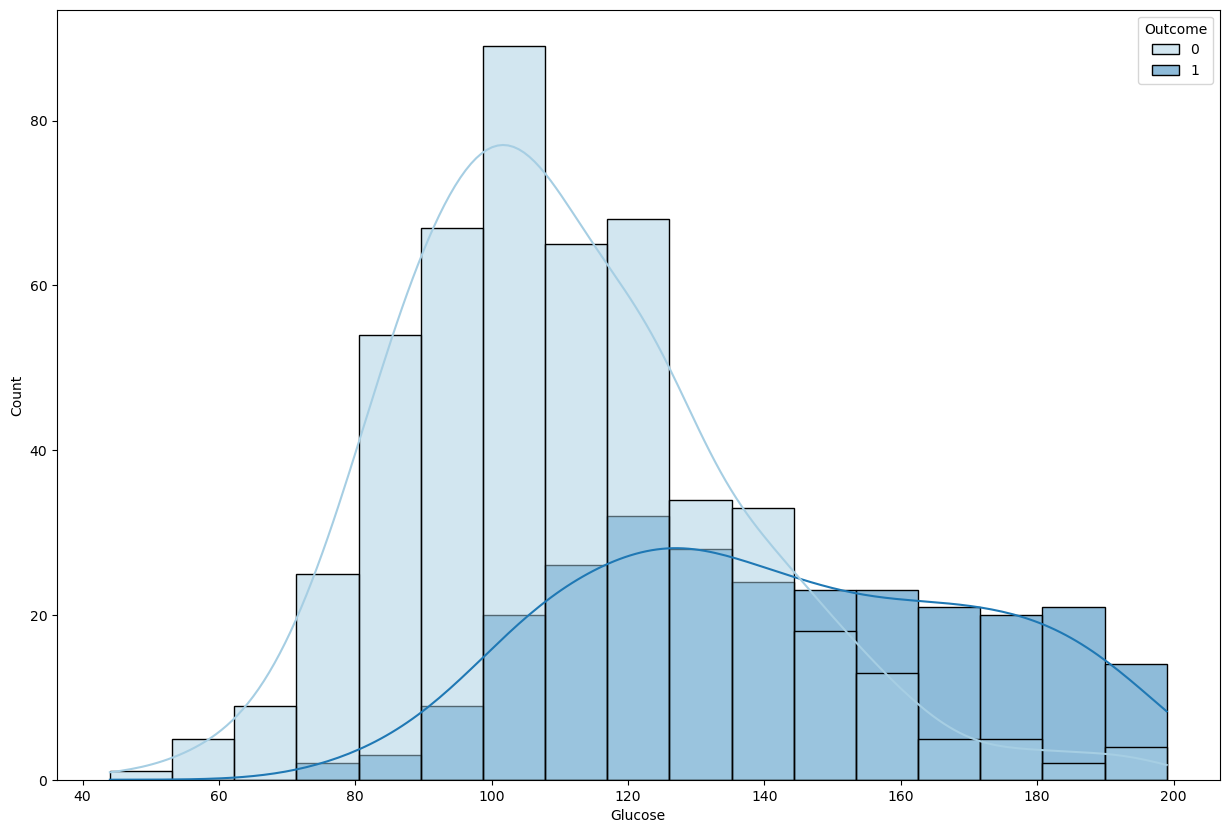

In [25]:
sns.histplot(x="Glucose", hue="Outcome", data=df, kde=True, palette=random.choice(pallete))

<Axes: xlabel='Insulin', ylabel='Count'>

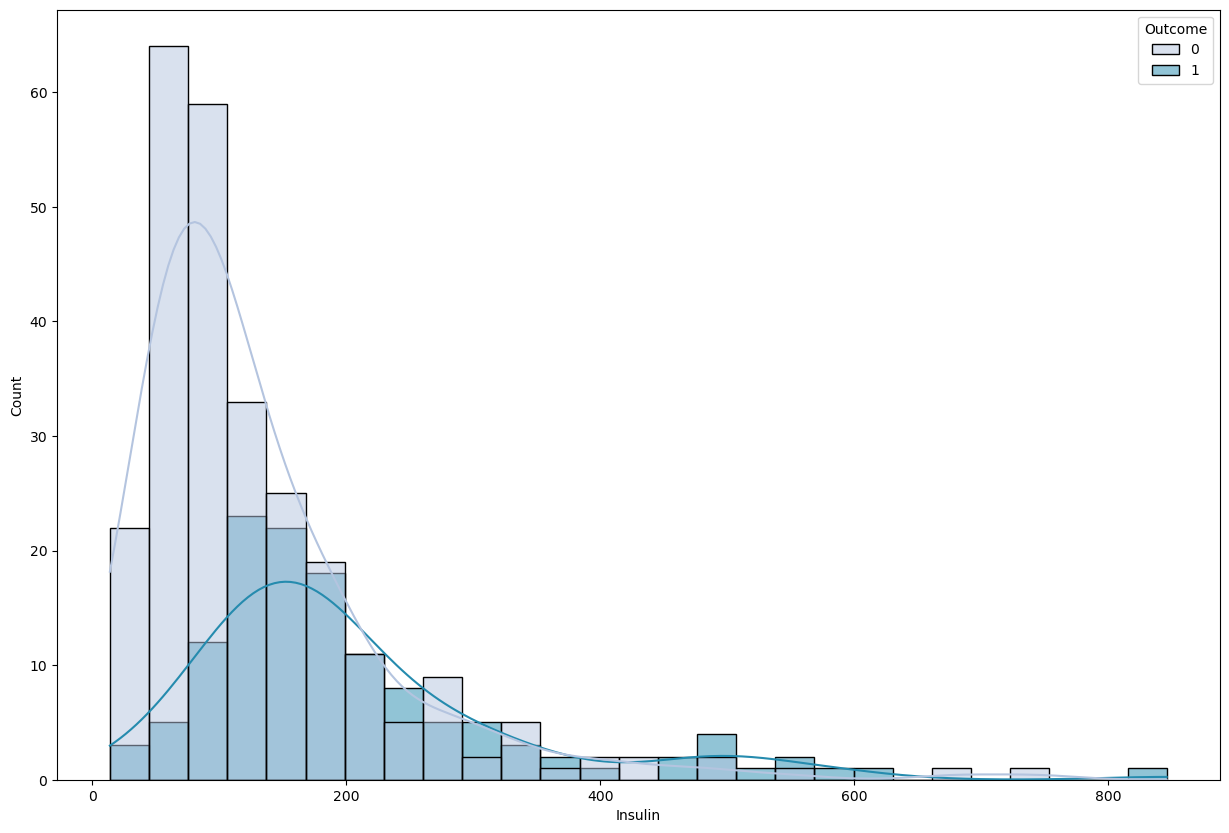

In [27]:
sns.histplot(x="Insulin", hue="Outcome", data=df, kde=True, palette=random.choice(pallete))

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Count'>

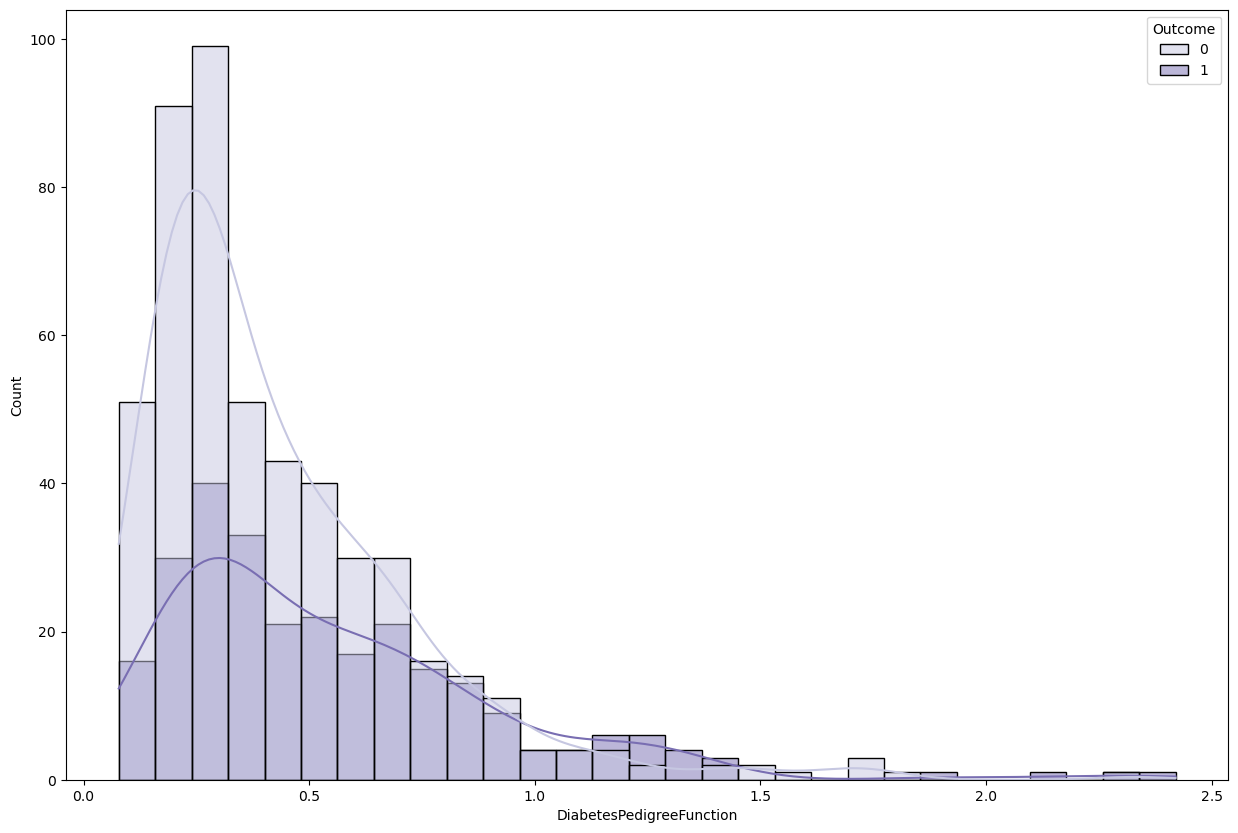

In [30]:
sns.histplot(x="DiabetesPedigreeFunction", hue="Outcome", data=df, kde=True, palette=random.choice(pallete))

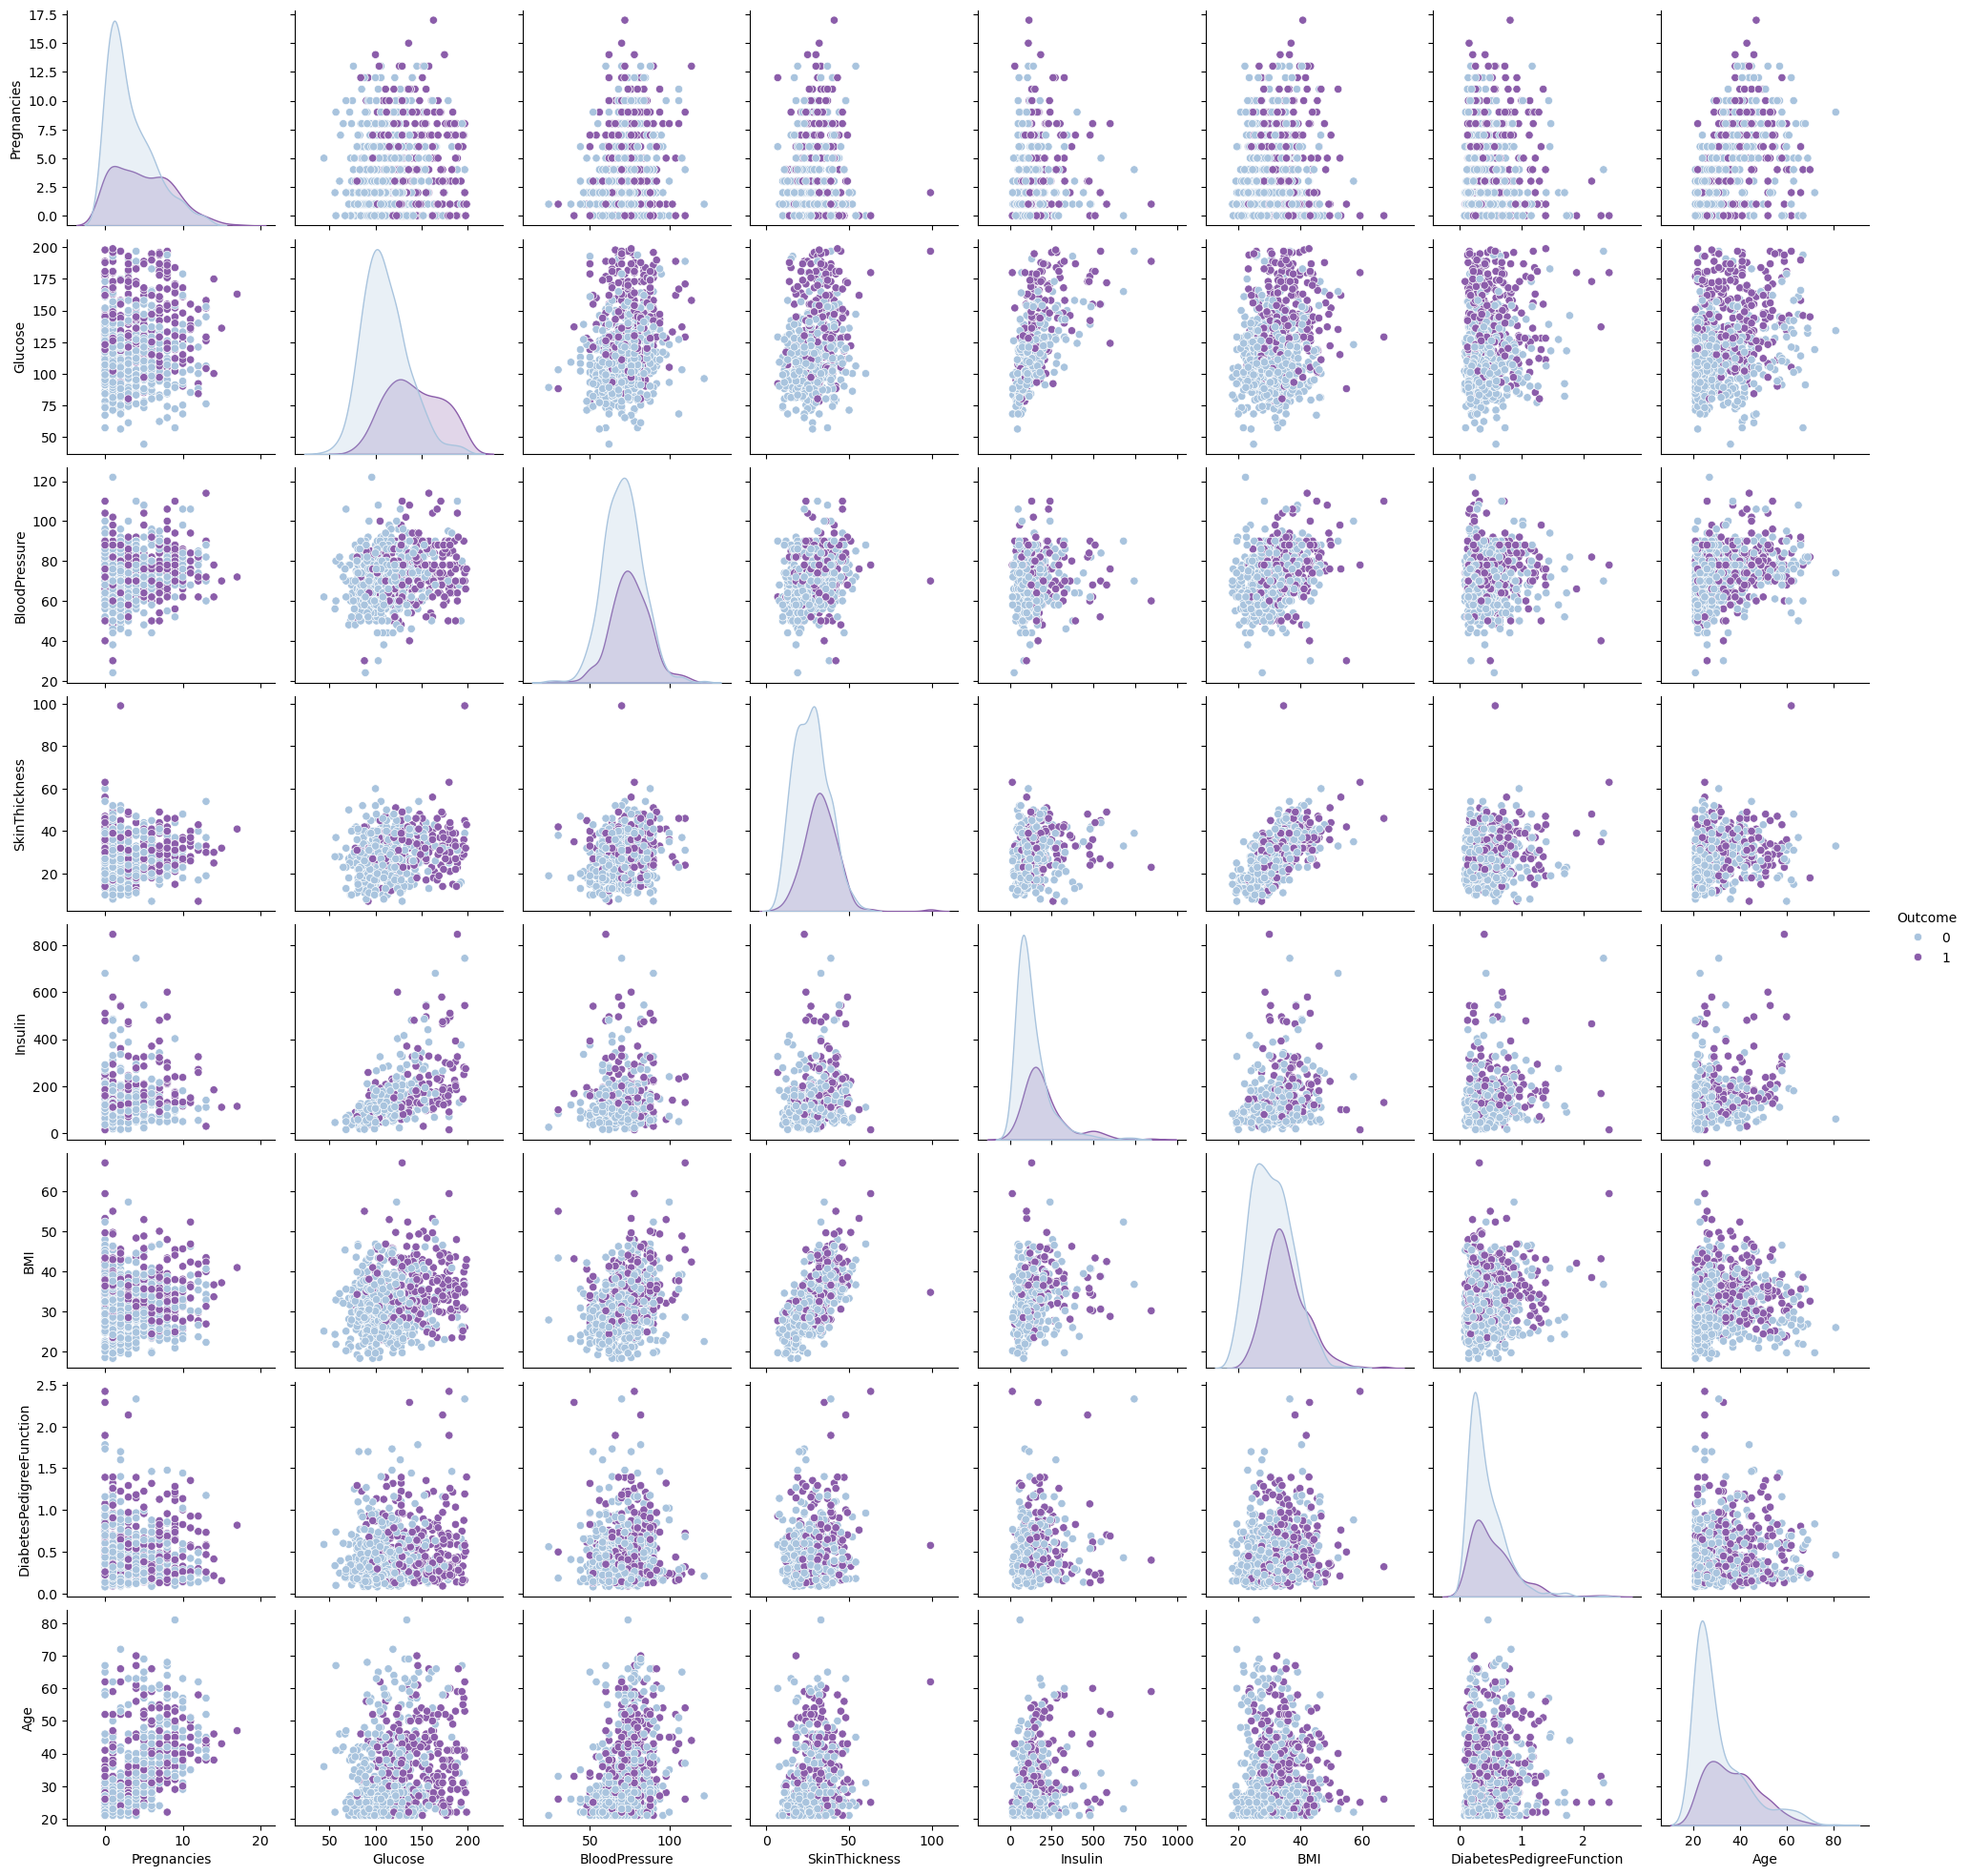

In [31]:
sns.pairplot(df, hue='Outcome',palette=random.choice(pallete))

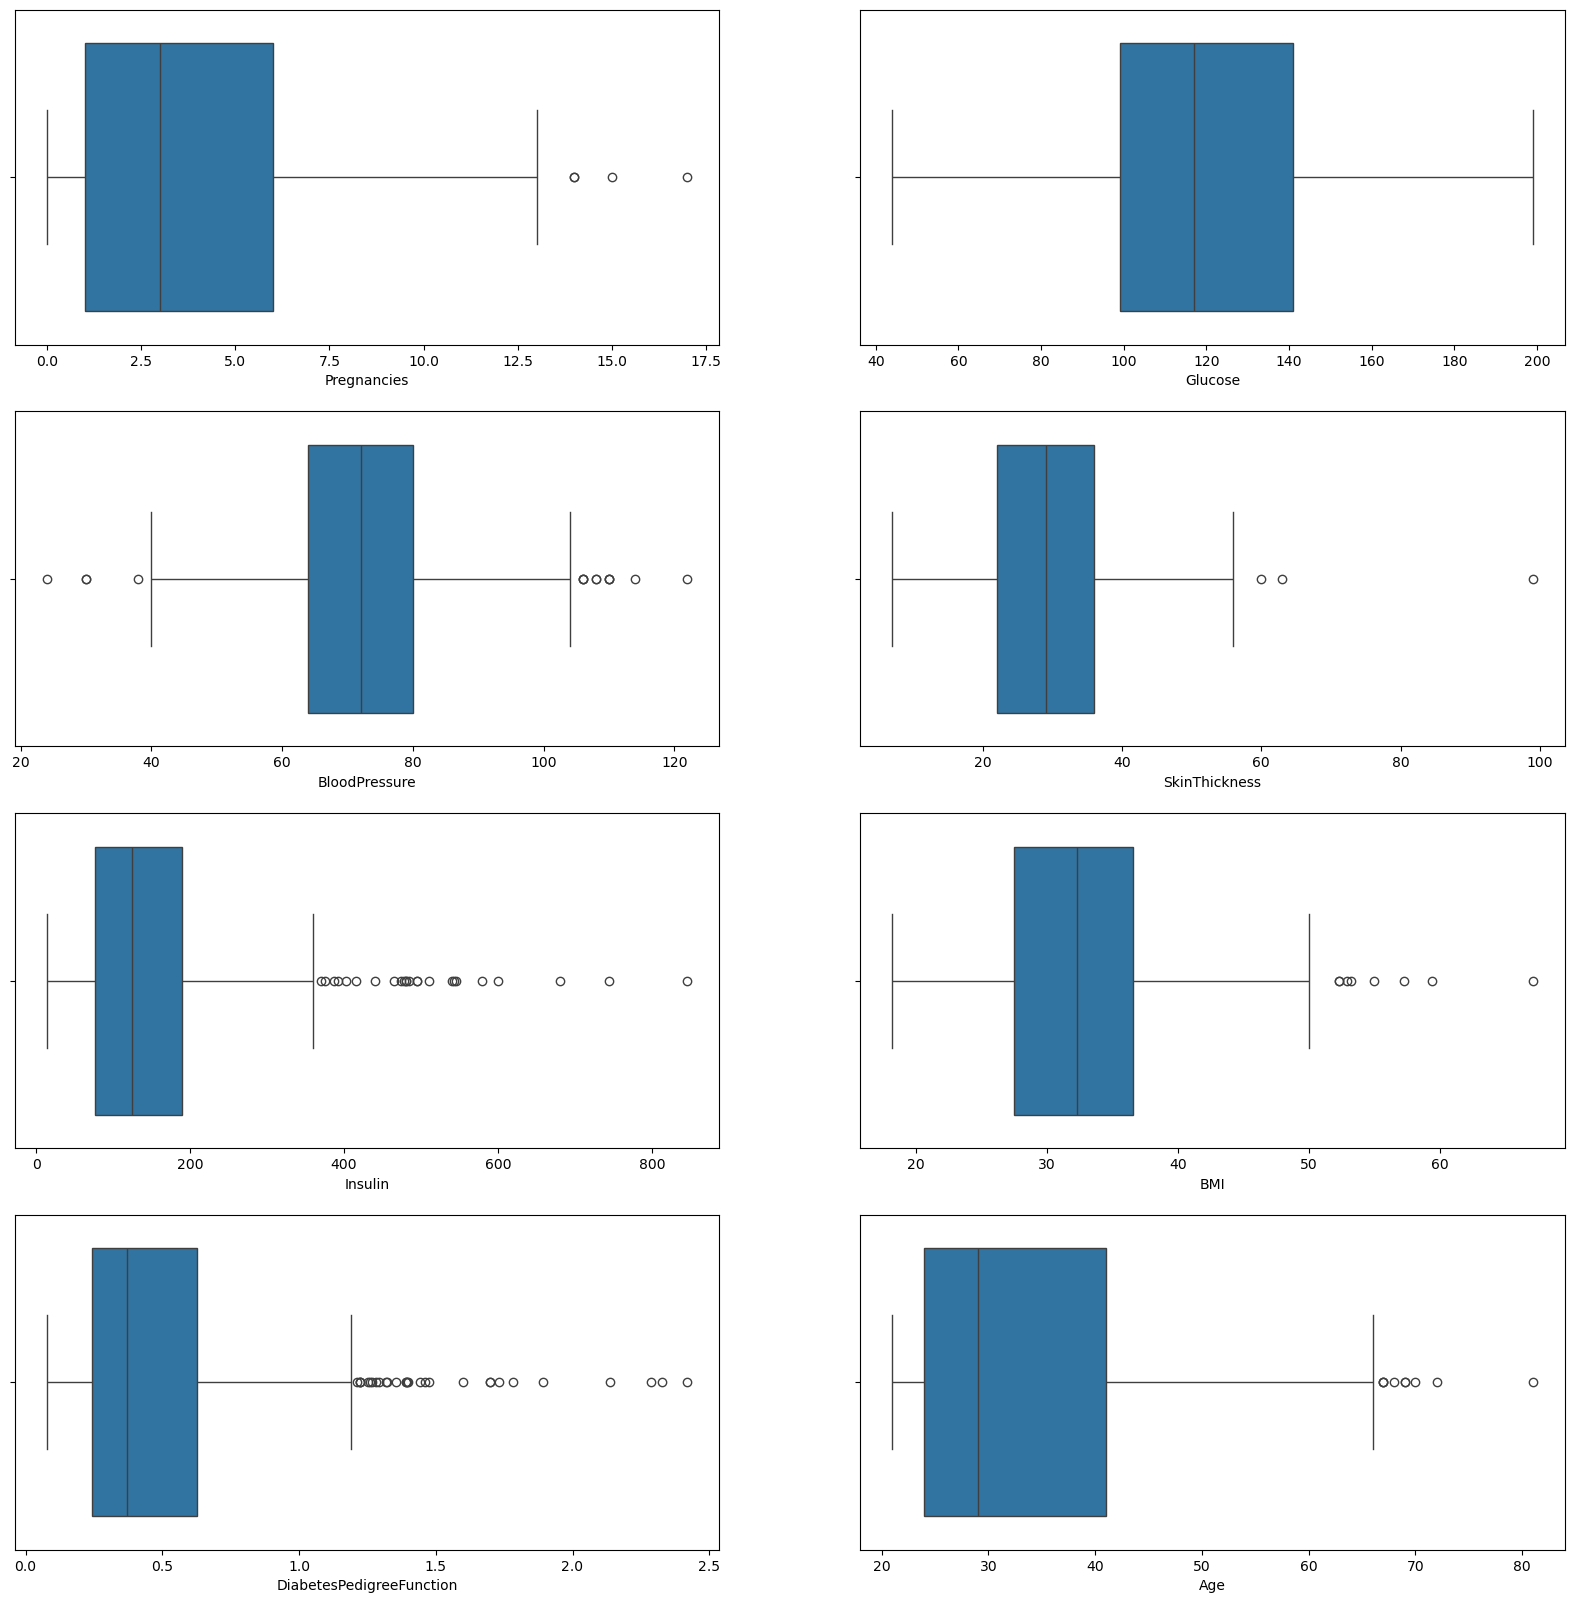

In [33]:
fig, axs = plt.subplots(4, 2, figsize=(20,20))
axs = axs.flatten()
for i in range(len(df.columns)-1):
    sns.boxplot(data=df, x=df.columns[i], ax=axs[i],)

Text(0.5, 1.0, 'Correlation Map')

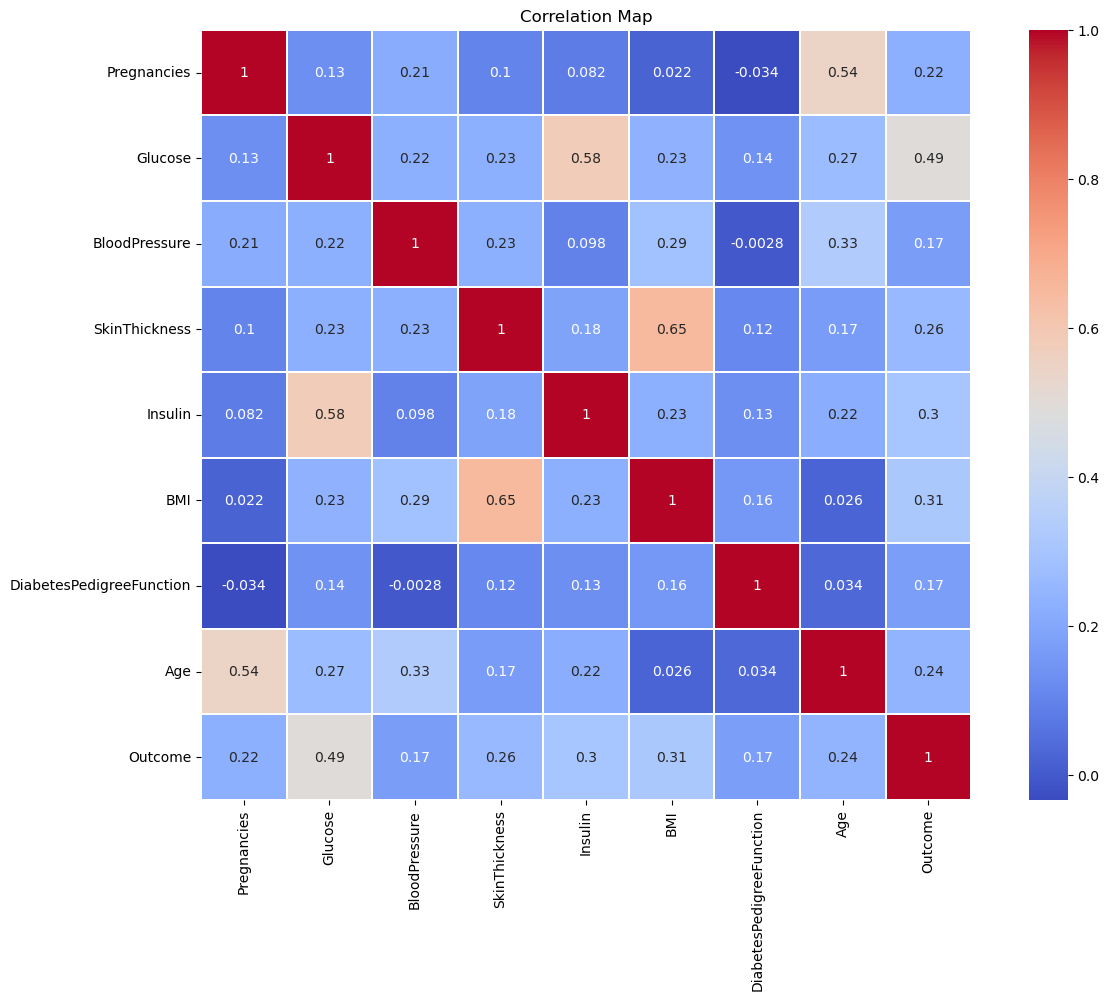

In [34]:
sns.heatmap(df.corr(), linewidths=0.1, vmax=1.0, square=True, cmap='coolwarm', linecolor='white', annot=True).set_title("Correlation Map")

In [35]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [37]:
df.drop(columns=["Insulin"], inplace=True)

In [38]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,67.100000,2.420000,81.000000,1.000000


In [39]:
df.skew()

Pregnancies                 0.901674
Glucose                     0.530989
BloodPressure               0.134153
SkinThickness               0.690619
BMI                         0.593970
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64

In [57]:
df["BMI"].replace(to_replace=np.nan,value=df["BMI"].median(), )
df["Pregnancies"].replace(to_replace=np.nan,value=df["Pregnancies"].median(), )

# Normal
df["Glucose"].replace(to_replace=np.nan,value=df["Glucose"].mean(), )
df["BloodPressure"].replace(to_replace=np.nan,value=df["BloodPressure"].mean(), )
df["SkinThickness"].replace(to_replace=np.nan,value=df["SkinThickness"].mean(), )

0      35.00000
1      29.00000
2      29.15342
3      23.00000
4      35.00000
         ...   
763    29.15342
764    27.00000
765    23.00000
766    29.15342
767    31.00000
Name: SkinThickness, Length: 768, dtype: float64

In [41]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

Pregnancies                  5.0000
Glucose                     40.5000
BloodPressure               16.0000
SkinThickness                7.0000
BMI                          9.1000
DiabetesPedigreeFunction     0.3825
Age                         17.0000
Outcome                      1.0000
dtype: float64


In [42]:
df_out = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f'Before: {df.shape}, After: {df_out.shape}')

Before: (768, 8), After: (627, 8)


In [43]:
for col in df.columns[:-1]:
    up_out = df[col].quantile(0.90)
    low_out = df[col].quantile(0.10)
    med = df[col].median()
#     print(col, up_out, low_out, med)
    df[col] = np.where(df[col] > up_out, med, df[col])
    df[col] = np.where(df[col] < low_out, med, df[col])

In [44]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.213542,119.185461,72.397794,28.988775,32.127083,0.411184,31.007812,0.348958
std,2.561112,18.584971,7.302671,4.533622,4.047594,0.171833,7.469534,0.476951
min,0.000000,87.000000,58.000000,18.000000,24.000000,0.165000,22.000000,0.000000
25%,1.000000,106.000000,68.000000,29.000000,29.600000,0.278000,25.000000,0.000000
50%,3.000000,117.000000,72.202592,29.153420,32.300000,0.372500,29.000000,0.000000
75%,5.000000,129.000000,76.000000,29.153420,34.500000,0.514000,36.000000,1.000000
max,9.000000,167.000000,88.000000,40.000000,41.500000,0.878000,51.000000,1.000000


In [45]:
X = df_out[df_out.columns[:-1]]
y = df_out['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [46]:
norm = MinMaxScaler().fit(X_train)
X_train_norm = norm.transform(X_train)
X_test_norm = norm.transform(X_test)

In [47]:
log_params = {'C': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 10, 100, 100]} 
log_model = GridSearchCV(LogisticRegression(), log_params, cv=5)
log_model.fit(X_train_norm, y_train)
log_pred = log_model.predict(X_test_norm)

In [48]:
rf_params = {'criterion' : ['gini', 'entropy'],
             'n_estimators': list(range(60, 140, 20)),
             'max_depth': list(range(3, 20, 2))}
rf_model = GridSearchCV(RandomForestClassifier(), rf_params, cv=5)
rf_model.fit(X_train_norm, y_train)
rf_pred = rf_model.predict(X_test_norm)

In [49]:
knn_params = {'n_neighbors': list(range(1,50))}
knn_model = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_model.fit(X_train_norm, y_train)
knn_pred = knn_model.predict(X_test_norm)

In [50]:
print("Logistic Regression: \n", classification_report(y_test, log_pred)) 
print("\nRandom Forest Classifier: \n", classification_report(y_test, rf_pred)) 
print("\nK Neighbors Classifier: \n", classification_report(y_test, knn_pred)) 

Logistic Regression: 
               precision    recall  f1-score   support

           0       0.75      0.93      0.83        83
           1       0.75      0.42      0.54        43

    accuracy                           0.75       126
   macro avg       0.75      0.67      0.68       126
weighted avg       0.75      0.75      0.73       126


Random Forest Classifier: 
               precision    recall  f1-score   support

           0       0.78      0.82      0.80        83
           1       0.62      0.56      0.59        43

    accuracy                           0.73       126
   macro avg       0.70      0.69      0.69       126
weighted avg       0.72      0.73      0.73       126


K Neighbors Classifier: 
               precision    recall  f1-score   support

           0       0.72      0.94      0.82        83
           1       0.72      0.30      0.43        43

    accuracy                           0.72       126
   macro avg       0.72      0.62      0.62      

In [52]:
labels = ["Not Diabetic", "Diabetic"]
cm  = confusion_matrix(y_test, log_pred)
plt.figure()
#plot_confusion_matrix(cm, hide_ticks=True, cmap="Reds")
#plt.xticks(range(2), labels, fontsize=14)
#plt.yticks(range(2), labels, fontsize=14)
plt.show()

<Figure size 1500x1000 with 0 Axes>

In [54]:
labels = ["Not Diabetic", "Diabetic"]
cm  = confusion_matrix(y_test, rf_pred)
plt.figure()
#plot_confusion_matrix(cm, hide_ticks=True, cmap="Blues")
#plt.xticks(range(2), labels, fontsize=14)
#plt.yticks(range(2), labels, fontsize=14)
plt.show()

<Figure size 1500x1000 with 0 Axes>

In [56]:
labels = ["Not Diabetic", "Diabetic"]
cm  = confusion_matrix(y_test, knn_pred)
plt.figure()
#plot_confusion_matrix(cm, hide_ticks=True, cmap="Greens")
#plt.xticks(range(2), labels, fontsize=14)
#plt.yticks(range(2), labels, fontsize=14)
plt.show()

<Figure size 1500x1000 with 0 Axes>